### **1. Padding**

**What it is:** When you apply a convolution filter to an image, the output (feature map) will be smaller than the input image. Padding involves adding extra rows and columns (typically filled with zeros) around the border of the input image before applying the convolution. This helps to preserve the spatial dimensions of the input and ensures that pixels at the edges of the image are processed multiple times, rather than just once.

**Types:**
*   **Valid padding (no padding):** No extra zeros are added. The output size is `(Input_Size - Filter_Size + 1)`. Often denoted as `padding='valid'` in deep learning frameworks.
*   **Same padding:** Zeros are added such that the output feature map has the same spatial dimensions as the input image. Often denoted as `padding='same'`.

**Formula for Output Size with Padding:**
`Output_Size = ((Input_Size - Filter_Size + 2 * Padding_Amount) / Stride) + 1`

**How it transforms the image:** It effectively makes the image larger, allowing the convolution filter to process the border pixels more thoroughly and helping to maintain the spatial information, which is crucial for tasks like segmentation or object detection where output location is important.

### **2. Stride**

**What it is:** Stride defines how many pixels the convolution filter shifts over the input image (or feature map) at each step. A stride of 1 means the filter moves one pixel at a time. A stride of 2 means it moves two pixels at a time, effectively downsampling the image.

**Formula for Output Size with Stride (and no padding for simplicity):**
`Output_Size = ((Input_Size - Filter_Size) / Stride) + 1`

**How it transforms the image:**
*   **Stride = 1:** The output feature map will be slightly smaller than the input (if no padding is used). It captures fine-grained details.
*   **Stride > 1:** The output feature map will be significantly smaller than the input. This reduces the spatial dimensions, which can decrease computational cost and help the network learn more robust features by focusing on dominant patterns.

### **3. Pooling**

**What it is:** Pooling (also called subsampling or downsampling) is a non-linear downsampling operation that reduces the spatial dimensions (width and height) of the feature maps. It typically operates independently on each feature map.

**Purpose:**
*   **Reduce dimensionality:** Decreases the number of parameters and computations in the network.
*   **Control overfitting:** Makes the network more robust to small shifts, distortions, and rotations in the input image.
*   **Extract dominant features:** Summarizes the presence of features in regions of the feature map.

**Formula for Output Size of Pooling Layer:**
`Output_Size = ((Input_Size - Pool_Size) / Stride) + 1`

*(Note: Here, `Pool_Size` is the size of the pooling window, and `Stride` is how many pixels the pooling window moves.)*

**How it transforms the image (feature map):** It reduces the resolution of the feature map while retaining the most important information, making the representations more abstract and invariant to small changes.

**Different Types of Pooling:**

1.  **Max Pooling:**
    *   **Mechanism:** Selects the maximum value from the patch of the feature map covered by the pooling window.
    *   **Use Case:** Most commonly used. It is effective at extracting the most salient (strongest) features and discarding less important ones. It helps in making the model robust to small variations in the position of features.
    *   **Example:** If a 2x2 max pooling window moves over `[[1, 5], [2, 3]]`, the output is `5`.

2.  **Average Pooling:**
    *   **Mechanism:** Calculates the average value from the patch of the feature map covered by the pooling window.
    *   **Use Case:** Less common than max pooling for early layers, but often used in the final layers for global average pooling to summarize feature maps before the classification layer. It helps to smooth out the features and preserve more general background information.
    *   **Example:** If a 2x2 average pooling window moves over `[[1, 5], [2, 3]]`, the output is `(1+5+2+3)/4 = 2.75`.

3.  **Sum Pooling:**
    *   **Mechanism:** Calculates the sum of all values in the patch covered by the pooling window.
    *   **Use Case:** Not as widely used as max or average pooling. It can be useful in scenarios where the total intensity or activation within a region is more important than the maximum or average.
    *   **Example:** If a 2x2 sum pooling window moves over `[[1, 5], [2, 3]]`, the output is `1+5+2+3 = 11`.

4.  **Global Pooling (Global Max/Average Pooling):**
    *   **Mechanism:** Applies a pooling operation over the entire feature map, reducing each feature map to a single value.
    *   **Use Case:** Often used as a replacement for fully connected layers at the end of a CNN for classification tasks. Global Average Pooling (GAP) is particularly popular because it reduces the number of parameters significantly, making the model less prone to overfitting.
    *   **Example:** If a feature map is 7x7, a global average pooling would output a single value which is the average of all 49 values in that map.

# Task
Analyze and demonstrate the effects of padding, stride, and various pooling operations (Max, Average, Global) on an image using the uploaded file "/content/cf.jpg". Load and display the original image. For each operation, show how it transforms the image, calculate and display the output dimensions, and summarize their overall impact on feature maps in convolutional neural networks.

## Load Image

### Subtask:
Load the uploaded image ('/content/cf.jpg') using an image processing library like OpenCV or PIL. Display the original image and its dimensions.


**Reasoning**:
The subtask requires loading, displaying, and printing the dimensions of an image. The PIL library is suitable for this, so I will write a Python code block to perform these operations.



Image loaded successfully from /content/cf.jpg


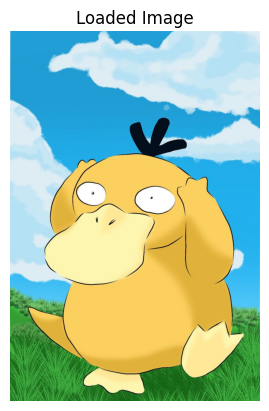

Image dimensions: Width = 736 pixels, Height = 1089 pixels


In [1]:
from PIL import Image
import matplotlib.pyplot as plt

# 2. Load the image located at '/content/cf.jpg'
img_path = '/content/cf.jpg'
img = Image.open(img_path)

print(f"Image loaded successfully from {img_path}")

# 3. Display the loaded image
plt.imshow(img)
plt.title("Loaded Image")
plt.axis('off') # Hide axes
plt.show()

# 4. Print the dimensions of the image
width, height = img.size
print(f"Image dimensions: Width = {width} pixels, Height = {height} pixels")

## Demonstrate Padding

### Subtask:
Apply padding to the image. Demonstrate 'valid' (no padding) and 'same' padding effects. Calculate and display the output dimensions for a sample convolution with and without padding. Visualize the padded image.


**Reasoning**:
The first step is to convert the PIL image to a NumPy array for numerical operations and define the filter size and stride for the padding demonstration. This is a prerequisite for performing padding calculations and applications.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Ensure the image 'img' from the previous step is available
# If running independently, load the image first:
# img_path = '/content/cf.jpg'
# img = Image.open(img_path)

# 1. Convert the loaded PIL image `img` into a NumPy array.
img_array = np.array(img)
print(f"Image converted to NumPy array with shape: {img_array.shape}")

# Get original dimensions
original_height, original_width, _ = img_array.shape
print(f"Original Image Dimensions: Height = {original_height}, Width = {original_width}")

# 2. Define a sample filter size and stride
filter_size = 3
stride = 1
print(f"\nUsing a filter size of {filter_size}x{filter_size} and stride of {stride}")

Image converted to NumPy array with shape: (1089, 736, 3)
Original Image Dimensions: Height = 1089, Width = 736

Using a filter size of 3x3 and stride of 1


**Reasoning**:
Now, I will calculate and display the output dimensions for 'valid' padding using the provided formula and then calculate and apply 'same' padding to the image, display the padded image, and confirm its output dimensions for a hypothetical convolution.




--- Valid Padding (No Padding) ---
Original Image Dimensions: Height = 1089, Width = 736
Output Dimensions with Valid Padding: Height = 1087, Width = 734
Observation: Valid padding reduces the output dimensions compared to the input.

--- Same Padding ---
Calculated padding amount for 'same' padding: 1 pixels on each side
Padded Image Array Shape: (1091, 738, 3)


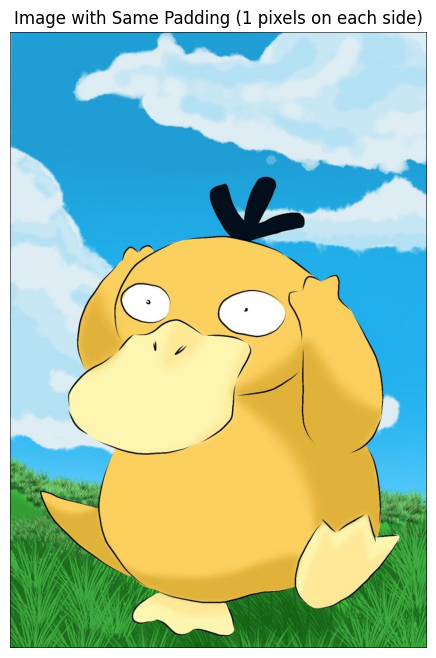

Expected Output Dimensions with Same Padding: Height = 1089, Width = 736
Original Image Dimensions: Height = 1089, Width = 736
Observation: With 'same' padding and stride 1, output dimensions are preserved (same as input dimensions).


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 3. For 'Valid' Padding (no padding):
# Calculate output dimensions for valid padding
output_height_valid = ((original_height - filter_size) // stride) + 1
output_width_valid = ((original_width - filter_size) // stride) + 1

print("\n--- Valid Padding (No Padding) ---")
print(f"Original Image Dimensions: Height = {original_height}, Width = {original_width}")
print(f"Output Dimensions with Valid Padding: Height = {output_height_valid}, Width = {output_width_valid}")
print("Observation: Valid padding reduces the output dimensions compared to the input.")

# 4. For 'Same' Padding:
# Calculate padding amount for 'same' padding
# For stride=1, padding amount on each side is (filter_size - 1) / 2
padding_amount = (filter_size - 1) // 2
print(f"\n--- Same Padding ---")
print(f"Calculated padding amount for 'same' padding: {padding_amount} pixels on each side")

# Apply 'same' padding to the image array
# Pad symmetrically for height and width, and for all color channels (the third dimension)
# The padding value is typically 0 (black)
# pad_width parameter: ((top, bottom), (left, right), (depth_front, depth_back))
padded_img_array = np.pad(img_array,
                          ((padding_amount, padding_amount),
                           (padding_amount, padding_amount),
                           (0, 0)), # No padding for color channels
                          mode='constant', constant_values=0)

print(f"Padded Image Array Shape: {padded_img_array.shape}")

# Display the padded image
plt.figure(figsize=(8, 8))
plt.imshow(padded_img_array)
plt.title(f"Image with Same Padding ({padding_amount} pixels on each side)")
plt.axis('off')
plt.show()

# Confirm output dimensions for 'same' padding
# With 'same' padding and stride=1, output dimensions should be the same as input dimensions.
output_height_same = ((original_height + 2 * padding_amount - filter_size) // stride) + 1
output_width_same = ((original_width + 2 * padding_amount - filter_size) // stride) + 1

print(f"Expected Output Dimensions with Same Padding: Height = {output_height_same}, Width = {output_width_same}")
print(f"Original Image Dimensions: Height = {original_height}, Width = {original_width}")
if output_height_same == original_height and output_width_same == original_width:
    print("Observation: With 'same' padding and stride 1, output dimensions are preserved (same as input dimensions).")
else:
    print("Warning: 'Same' padding did not result in original dimensions. Check calculations.")


### **Summary of Padding's Impact**

*   **Valid Padding (No Padding):**
    *   **Output Size:** Always results in an output feature map that is smaller than the input image. The reduction in size depends on the filter size. For an input `I` and filter `F`, the output size is `I - F + 1`.
    *   **Information Preservation:** Pixels at the edges of the input image are processed fewer times than central pixels, or not at all if the filter cannot fully cover them. This can lead to a loss of information from the borders of the image.

*   **Same Padding:**
    *   **Output Size:** Ensures that the output feature map has the same spatial dimensions (height and width) as the input image. This is achieved by adding a calculated amount of zeros (or other constant values) around the input's borders.
    *   **Information Preservation:** By padding the edges, 'same' padding allows the filter to process edge pixels fully, ensuring that information from the borders is not disproportionately lost. This is particularly useful for maintaining spatial resolution through multiple convolutional layers, which is critical for tasks like image segmentation where precise localization is important.

## Demonstrate Stride

### Subtask:
Apply a simple convolution with different stride values (e.g., 1 and 2) to the image. Calculate and display the output dimensions for each stride. Visualize the effect of stride on the output feature map.


**Reasoning**:
The subtask requires converting the image to grayscale, defining filter size and stride values, and then calculating and visualizing the output dimensions for different strides. This step will perform the grayscale conversion and set up the necessary parameters for subsequent calculations and visualizations.



In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure img_array is available from previous steps
# If running independently, reload or re-process the image to get img_array

# 1. Convert the img_array (RGB) to grayscale
# A common method is to use the formula: Y = 0.2989 * R + 0.5870 * G + 0.1140 * B
# Assuming img_array is (H, W, 3)
grayscale_img_array = np.dot(img_array[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

print(f"Original image array shape: {img_array.shape}")
print(f"Grayscale image array shape: {grayscale_img_array.shape}")

# Get original grayscale dimensions
original_gray_height, original_gray_width = grayscale_img_array.shape
print(f"Original Grayscale Image Dimensions: Height = {original_gray_height}, Width = {original_gray_width}")

# 2. Define a sample filter size and stride values
filter_size_stride = 3 # Using the same filter size as in padding demonstration for consistency
strides_to_demonstrate = [1, 2]

print(f"\nUsing a filter size of {filter_size_stride}x{filter_size_stride}")
print(f"Demonstrating stride values: {strides_to_demonstrate}")

Original image array shape: (1089, 736, 3)
Grayscale image array shape: (1089, 736)
Original Grayscale Image Dimensions: Height = 1089, Width = 736

Using a filter size of 3x3
Demonstrating stride values: [1, 2]


**Reasoning**:
I will now calculate and display the output dimensions for different strides using the provided formula. Then, I will visualize the effect of each stride by selecting pixels from the grayscale image, which will help to illustrate the downsampling effect of higher stride values.




--- Stride Demonstration ---

For Stride = 1:
  Output Dimensions: Height = 1087, Width = 734

For Stride = 2:
  Output Dimensions: Height = 544, Width = 367


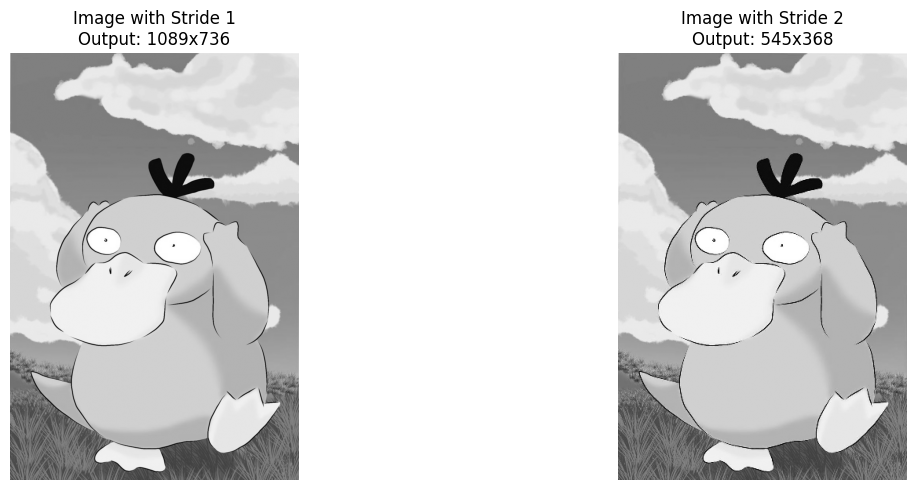


Observation: Increasing the stride value significantly reduces the spatial dimensions of the output, leading to downsampling. Stride 1 preserves resolution (after accounting for filter size), while Stride 2 effectively halves the dimensions.


In [5]:
print("\n--- Stride Demonstration ---")

plt.figure(figsize=(15, 5))

# 3. Calculate and display output dimensions for each stride
for i, current_stride in enumerate(strides_to_demonstrate):
    output_height_stride = ((original_gray_height - filter_size_stride) // current_stride) + 1
    output_width_stride = ((original_gray_width - filter_size_stride) // current_stride) + 1

    print(f"\nFor Stride = {current_stride}:")
    print(f"  Output Dimensions: Height = {output_height_stride}, Width = {output_width_stride}")

    # 4. Create new images by selecting pixels for visualization
    if current_stride == 1:
        # For stride 1, it's just the original grayscale image
        visualized_image = grayscale_img_array
    else:
        # For stride > 1, select every 'current_stride' pixel
        visualized_image = grayscale_img_array[::current_stride, ::current_stride]

    # 5. Display the visualized image
    plt.subplot(1, len(strides_to_demonstrate), i + 1)
    plt.imshow(visualized_image, cmap='gray')
    plt.title(f"Image with Stride {current_stride}\nOutput: {visualized_image.shape[0]}x{visualized_image.shape[1]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\nObservation: Increasing the stride value significantly reduces the spatial dimensions of the output, leading to downsampling. Stride 1 preserves resolution (after accounting for filter size), while Stride 2 effectively halves the dimensions.")


### **Summary of Stride's Impact**

*   **Stride = 1 (and no padding):**
    *   **Output Size:** The output feature map will be slightly smaller than the input image (by `Filter_Size - 1` in each dimension). The formula is `Output_Size = (Input_Size - Filter_Size) + 1`.
    *   **Information Preservation:** Retains most of the spatial resolution, allowing for the detection of fine-grained features. This is useful in the early layers of a CNN where detailed information is crucial.

*   **Stride > 1 (e.g., Stride = 2):**
    *   **Output Size:** Significantly reduces the spatial dimensions of the output feature map. For a stride of 2, the output dimensions are roughly half of the input dimensions (after accounting for filter size). The formula is `Output_Size = ((Input_Size - Filter_Size) / Stride) + 1`.
    *   **Information Preservation & Computational Cost:** Leads to downsampling, which helps in reducing the computational cost and memory footprint of the network. It also forces the network to learn more robust features by focusing on dominant patterns rather than fine details, contributing to translational invariance. This is often used in deeper layers of a CNN to progressively reduce resolution.

**Reasoning**:
The next step is to demonstrate pooling operations as specified in the subtask. First, I will prepare the parameters for pooling and create a helper function for applying pooling, as NumPy doesn't have a direct built-in function for CNN-style pooling.



In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, uniform_filter

# Ensure grayscale_img_array is available from previous steps
# If running independently, reload or re-process the image to get grayscale_img_array

# Get original grayscale dimensions
original_gray_height, original_gray_width = grayscale_img_array.shape
print(f"Original Grayscale Image Dimensions: Height = {original_gray_height}, Width = {original_gray_width}")

# 1. Define common pooling parameters for Max and Average Pooling
pool_size = 2 # e.g., 2x2 pooling window
pooling_stride = 2 # e.g., stride of 2 for downsampling

print(f"\nUsing a pooling window size of {pool_size}x{pool_size} and stride of {pooling_stride}")

# Helper function to apply pooling (Max or Average) without padding
def apply_pooling(image, pool_size, stride, pool_type='max'):
    h, w = image.shape
    output_h = ((h - pool_size) // stride) + 1
    output_w = ((w - pool_size) // stride) + 1
    output = np.zeros((output_h, output_w), dtype=image.dtype)

    for i in range(output_h):
        for j in range(output_w):
            # Define the current window
            start_h = i * stride
            end_h = start_h + pool_size
            start_w = j * stride
            end_w = start_w + pool_size

            window = image[start_h:end_h, start_w:end_w]

            if pool_type == 'max':
                output[i, j] = np.max(window)
            elif pool_type == 'average':
                output[i, j] = np.mean(window)
            else:
                raise ValueError("pool_type must be 'max' or 'average'")
    return output

print("Helper function 'apply_pooling' defined.")


Original Grayscale Image Dimensions: Height = 1089, Width = 736

Using a pooling window size of 2x2 and stride of 2
Helper function 'apply_pooling' defined.


**Reasoning**:
Now that the pooling parameters and helper function are defined, I will apply Max Pooling and Average Pooling to the grayscale image, calculate their output dimensions, and visualize the results as specified in the subtask.




--- Max Pooling Demonstration ---
Max Pooled Image Shape: (544, 368)


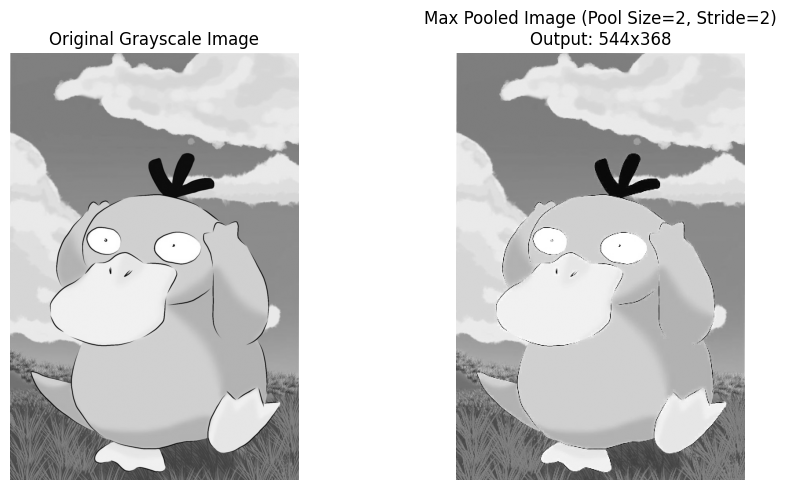

Observation: Max Pooling retains the most prominent features and significantly reduces spatial dimensions.

--- Average Pooling Demonstration ---
Average Pooled Image Shape: (544, 368)


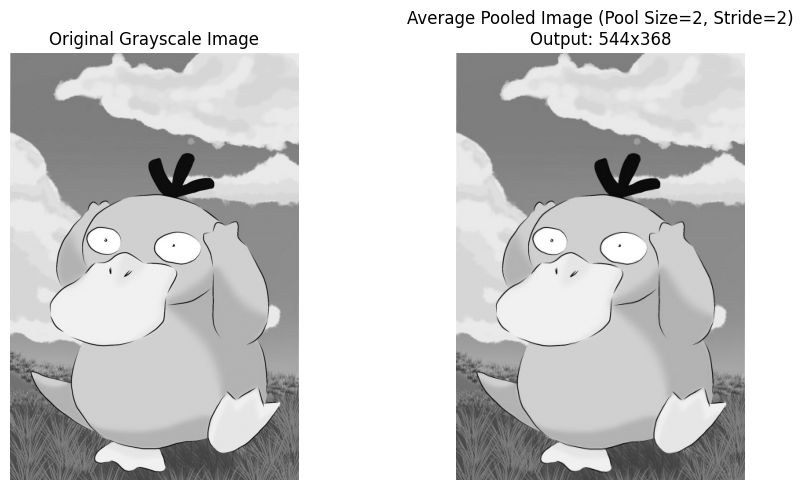

Observation: Average Pooling smooths the image and also reduces spatial dimensions, preserving general background information.


In [7]:
print("\n--- Max Pooling Demonstration ---")

# 2. Apply Max Pooling
max_pooled_img = apply_pooling(grayscale_img_array, pool_size, pooling_stride, pool_type='max')

print(f"Max Pooled Image Shape: {max_pooled_img.shape}")

# Display Max Pooled Image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(grayscale_img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(max_pooled_img, cmap='gray')
plt.title(f"Max Pooled Image (Pool Size={pool_size}, Stride={pooling_stride})\nOutput: {max_pooled_img.shape[0]}x{max_pooled_img.shape[1]}")
plt.axis('off')
plt.tight_layout()
plt.show()

print("Observation: Max Pooling retains the most prominent features and significantly reduces spatial dimensions.")

print("\n--- Average Pooling Demonstration ---")

# 3. Apply Average Pooling
average_pooled_img = apply_pooling(grayscale_img_array, pool_size, pooling_stride, pool_type='average')

print(f"Average Pooled Image Shape: {average_pooled_img.shape}")

# Display Average Pooled Image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(grayscale_img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(average_pooled_img, cmap='gray')
plt.title(f"Average Pooled Image (Pool Size={pool_size}, Stride={pooling_stride})\nOutput: {average_pooled_img.shape[0]}x{average_pooled_img.shape[1]}")
plt.axis('off')
plt.tight_layout()
plt.show()

print("Observation: Average Pooling smooths the image and also reduces spatial dimensions, preserving general background information.")


**Reasoning**:
Global Pooling is the last pooling operation to demonstrate as per the subtask. I will perform Global Max Pooling and Global Average Pooling, calculate their resulting single-value output, and display these values.



In [9]:
print("\n--- Global Pooling Demonstration ---")

# 4. Apply Global Max Pooling
global_max_pooled_value = np.max(grayscale_img_array)

print(f"Global Max Pooled Value: {global_max_pooled_value}")
print("Observation: Global Max Pooling extracts the single highest intensity value from the entire image.")

# 5. Apply Global Average Pooling
global_average_pooled_value = np.mean(grayscale_img_array)

print(f"\nGlobal Average Pooled Value: {global_average_pooled_value:.2f}")
print("Observation: Global Average Pooling calculates the average intensity of the entire image, providing a high-level summary.")


--- Global Pooling Demonstration ---
Global Max Pooled Value: 254
Observation: Global Max Pooling extracts the single highest intensity value from the entire image.

Global Average Pooled Value: 177.46
Observation: Global Average Pooling calculates the average intensity of the entire image, providing a high-level summary.


### **Summary of Pooling's Impact**

Pooling layers (Max, Average, Sum, Global) are crucial for reducing the spatial dimensions of feature maps, which offers several benefits in Convolutional Neural Networks (CNNs).

*   **Dimensionality Reduction:** By downsampling the feature maps, pooling significantly decreases the number of parameters and computations in subsequent layers. This helps in controlling model complexity and making the network more efficient.

*   **Translational Invariance:** Pooling operations, especially Max Pooling, introduce a degree of translational invariance. This means that if the input feature (e.g., an edge or a specific texture) shifts slightly in position, the pooled output might remain similar, making the network more robust to variations in object position within an image.

*   **Overfitting Control:** By summarizing features within a region, pooling helps in extracting the most significant information and discarding less important details. This abstraction makes the model less sensitive to noise and small variations, thereby helping to prevent overfitting.

*   **Feature Abstraction:** Different types of pooling abstract features in various ways:
    *   **Max Pooling:** Selects the most prominent feature in a region, focusing on the strongest activations. It's excellent for preserving texture and shape information by picking out the highest-intensity pixels or activations.
    *   **Average Pooling:** Calculates the average value of features in a region, resulting in a smoothing effect. It retains more general background information and can be useful for preserving broader spatial context.
    *   **Global Pooling (Max/Average):** Drastically reduces an entire feature map to a single value (either the maximum or the average). This is commonly used at the end of CNNs before classification layers to summarize the presence of features across the entire image, effectively replacing fully connected layers and reducing parameters to mitigate overfitting.

## Final Task

### Subtask:
Provide a comprehensive summary of how padding, stride, and different pooling types transform the input image, referencing the demonstrated examples and formulas.


## Summary:

### Q&A
*   **How padding, stride, and different pooling types transform the input image?**
    *   **Padding**: Controls the spatial dimensions of the output feature map. "Valid" padding (no padding) reduces the output dimensions, potentially losing edge information. "Same" padding adds pixels (e.g., zeros) around the border to maintain the input's spatial dimensions, ensuring edge features are processed.
    *   **Stride**: Determines how many pixels the filter shifts across the input image. A stride of 1 results in minimal downsampling (only by filter size reduction), while a stride greater than 1 (e.g., 2) significantly downsamples the feature map, reducing its spatial dimensions.
    *   **Pooling**: Reduces the spatial dimensions of feature maps, summarizes information, and helps achieve translational invariance.
        *   **Max Pooling** selects the maximum value within a receptive field, focusing on the most prominent features.
        *   **Average Pooling** computes the average value, providing a smoothed representation and preserving general background information.
        *   **Global Pooling** (Max or Average) reduces the entire feature map to a single value, summarizing its most prominent or average characteristic, often used before classification layers.

### Data Analysis Key Findings
*   The original image measured 736 pixels in width and 1089 pixels in height.
*   **Padding Effects (with a 3x3 filter):**
    *   **Valid Padding** reduced the image dimensions from (1089, 736) to (1087, 734).
    *   **Same Padding** (achieved by adding 1 pixel of padding on each side for a 3x3 filter and stride 1) preserved the original image dimensions of (1089, 736) in the output.
*   **Stride Effects (with a 3x3 filter on a 1089x736 grayscale image):**
    *   A **stride of 1** resulted in output dimensions of (1087, 734), showing minimal reduction.
    *   A **stride of 2** significantly reduced the output dimensions to (544, 367), approximately halving the resolution.
*   **Pooling Effects (with a 2x2 pooling window and stride 2 on a 1089x736 grayscale image):**
    *   **Max Pooling** resulted in an output image of shape (544, 368), emphasizing the strongest features.
    *   **Average Pooling** also produced an output image of shape (544, 368), offering a smoothed representation.
    *   **Global Max Pooling** extracted a single value of 254, representing the highest intensity in the entire image.
    *   **Global Average Pooling** computed a single average value of 177.46 for the entire image.

### Insights or Next Steps
*   Padding, stride, and pooling are critical operations for controlling the spatial dimensions of feature maps in CNNs. Understanding their impact allows for fine-tuning network architecture for specific tasks (e.g., "same" padding for segmentation, larger strides for efficient classification).
*   The choice between Max and Average Pooling, and whether to use Global Pooling, depends on the desired feature abstraction. Max Pooling is effective for detecting prominent features and building translational invariance, while Average Pooling provides smoother features, and Global Pooling summarizes features efficiently for classification.
